# VAYU — Data Preparation Pipeline
## Step 2: Data Cleaning

**Prerequisite:** Run `vayu_step1_setup.ipynb` first.

---

### What This Step Does

Step 1 was purely observation — we found two types of problems:
1. **Sentinel value 999** — CPCB code for sensor error. Not a real reading.
2. **Physically impossible values** — readings above the maximum a sensor can physically output.

This step fixes both, then handles the gaps that are left behind, and saves the result as the **master cleaned file** that all subsequent steps read from.

### Cleaning Operations in Order
1. Replace sentinel 999 → NaN
2. Apply physical range validation per pollutant
3. Forward fill short sensor dropout gaps (≤ 3 hours) within each city
4. Drop rows where all pollutants are still NaN after filling
5. Remove duplicate city + datetime rows
6. Parse and standardize datetime
7. Add derived time features (year, month, season etc.)
8. Derive AQI_category if not present
9. Before/after comparison visualizations
10. Save master cleaned file

> **Rule:** Every operation is logged with a before/after row count so you can see exactly what each step removed.

In [17]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.labelsize']    = 11
sns.set_palette('muted')

pd.set_option('display.max_columns', 60)

DATA_ROOT   = './data'
OUTPUT_ROOT = './data/cleaned'
SHARED_DIR  = os.path.join(OUTPUT_ROOT, '05_shared')
os.makedirs(SHARED_DIR, exist_ok=True)

cleaning_log = []

def log_step(step_name, rows_before, rows_after, notes=''):
    removed = rows_before - rows_after
    cleaning_log.append({
        'step'        : step_name,
        'rows_before' : rows_before,
        'rows_after'  : rows_after,
        'rows_removed': removed,
        'pct_removed' : round(removed / rows_before * 100, 3) if rows_before else 0,
        'notes'       : notes
    })
    flag = '  <- rows dropped' if removed > 0 else ''
    print(f'  [{step_name}]  {rows_before:,} -> {rows_after:,}  ({removed:,} removed, {removed/rows_before*100:.2f}%)  {notes}{flag}')

print('Setup complete.')

Setup complete.


---
## Section 1 — Load Primary Dataset

In [18]:
PRIMARY_FILE = os.path.join(DATA_ROOT, 'aqi_india_38cols_knn_final.csv')
print(f'Loading: {PRIMARY_FILE}\n')

df = pd.read_csv(PRIMARY_FILE, low_memory=False)

INITIAL_ROWS = len(df)
print(f'Loaded  : {INITIAL_ROWS:,} rows x {df.shape[1]} columns')

# Stricter pollutant keyword matching
# 'co' alone matches 'cloud_cover_percent' — use 'co_' to force underscore boundary
POLLUTANT_KEYWORDS = ['pm2', 'pm10', 'no2', 'so2', 'co_', 'o3', 'ozone', 'nh3', 'nox']
EXCLUDE_KEYWORDS   = ['cloud', 'cover', 'humidity', 'temp', 'pressure',
                      'wind', 'rain', 'solar', 'visibility', 'dew', 'uv']

pollutant_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if any(k in c.lower() for k in POLLUTANT_KEYWORDS)
    and not any(ex in c.lower() for ex in EXCLUDE_KEYWORDS)
]

city_col = next((c for c in df.columns if c.lower() in ['city', 'city_name']), None)
date_col = next((c for c in df.columns
                 if 'datetime' in c.lower() or c.lower() == 'date'
                 or 'timestamp' in c.lower()), None)
aqi_col  = next((c for c in df.columns if c.lower() in ['aqi', 'air_quality_index']), None)
cat_col  = next((c for c in df.columns
                 if 'category' in c.lower() or 'bucket' in c.lower()), None)

print(f'Pollutant cols : {pollutant_cols}')
print(f'City col       : {city_col}')
print(f'Date col       : {date_col}')
print(f'AQI col        : {aqi_col}')
print(f'Category col   : {cat_col}')

Loading: ./data/aqi_india_38cols_knn_final.csv

Loaded  : 842,160 rows x 31 columns
Pollutant cols : ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3']
City col       : city
Date col       : datetime
AQI col        : None
Category col   : aqi_category


In [19]:
# Snapshot raw data before ANY cleaning — used for before/after comparisons
df_raw_snapshot = df[pollutant_cols].copy()

raw_sentinel_counts = {}
for col in pollutant_cols:
    raw_sentinel_counts[col] = (pd.to_numeric(df[col], errors='coerce') == 999).sum()

print('RAW sentinel 999 counts per pollutant column:')
for col, count in raw_sentinel_counts.items():
    pct  = count / len(df) * 100
    flag = '  <- needs fixing' if count > 0 else ''
    print(f'  {col:<35} {count:>8,}  ({pct:.2f}%){flag}')
print(f'\nTotal sentinel values : {sum(raw_sentinel_counts.values()):,}')

RAW sentinel 999 counts per pollutant column:
  pm2_5_ugm3                                 0  (0.00%)
  pm10_ugm3                                  0  (0.00%)
  co_ugm3                                  124  (0.01%)  <- needs fixing
  no2_ugm3                                   0  (0.00%)
  so2_ugm3                                   0  (0.00%)
  o3_ugm3                                    0  (0.00%)

Total sentinel values : 124


---
## Section 2 — Operation 1: Replace Sentinel 999 → NaN

### Why Is 999 a Sentinel, Not a Real Value?

CPCB sensor documentation states that when a CAAQMS station goes offline, loses power, or produces an out-of-range reading, the system records **999** as a placeholder. It is a flag, not a measurement.

Real-world PM2.5 during the worst recorded pollution events in India (post-Diwali Delhi 2021) peaked around **900 µg/m³**. A value of exactly 999 is always a sentinel — it cannot be a real reading.

If we leave 999 in the dataset, the regression model will learn that PM2.5=999 predicts AQI=X, which is completely wrong and will destroy model accuracy.

In [20]:
rows_before  = len(df)
numeric_cols = df.select_dtypes(include=[np.number]).columns
replacements = 0

for col in numeric_cols:
    mask          = df[col] == 999
    replacements += mask.sum()
    df.loc[mask, col] = np.nan

rows_after = len(df)
log_step('Replace 999->NaN', rows_before, rows_after,
         f'{replacements:,} values replaced across {len(numeric_cols)} numeric columns')

print('\nNull counts in pollutant cols after sentinel replacement:')
for col in pollutant_cols:
    n   = df[col].isnull().sum()
    pct = n / len(df) * 100
    print(f'  {col:<35} {n:>8,}  ({pct:.2f}%)')

  [Replace 999->NaN]  842,160 -> 842,160  (0 removed, 0.00%)  1,477 values replaced across 18 numeric columns

Null counts in pollutant cols after sentinel replacement:
  pm2_5_ugm3                                 0  (0.00%)
  pm10_ugm3                                  0  (0.00%)
  co_ugm3                                  124  (0.01%)
  no2_ugm3                                   0  (0.00%)
  so2_ugm3                                   0  (0.00%)
  o3_ugm3                                    0  (0.00%)


---
## Section 3 — Operation 2: Physical Range Validation

### Unit-Aware Range Checking

This dataset stores all pollutants in **µg/m³** (visible in column names like `co_ugm3`). CO is traditionally reported in mg/m³ by WHO/CPCB, but this file has already converted it.

This matters critically:
- CO limit in **mg/m³** = 50
- CO limit in **µg/m³** = 50 × 1000 = **50,000**

Using 50 as the limit when the unit is µg/m³ would wipe out every valid CO reading. The fix: check the column name for `ugm3` and apply the correct limit table.

| Pollutant | Max in µg/m³ | Max in mg/m³ |
|---|---|---|
| PM2.5 | 1,000 | — |
| PM10 | 1,500 | — |
| NO2 | 500 | — |
| SO2 | 500 | — |
| CO | **50,000** | **50** |
| O3 | 300 | — |
| NH3 | 400 | — |

In [21]:
VALID_RANGES_UGM3 = {
    'pm2'  : (0, 1000),
    'pm10' : (0, 1500),
    'no2'  : (0, 500),
    'so2'  : (0, 500),
    'co'   : (0, 50000),   # 50 mg/m3 = 50,000 ug/m3
    'ozone': (0, 300),
    'o3'   : (0, 300),
    'nh3'  : (0, 400),
    'nox'  : (0, 1000),
}

VALID_RANGES_MGM3 = {
    'pm2'  : (0, 1000),
    'pm10' : (0, 1500),
    'no2'  : (0, 500),
    'so2'  : (0, 500),
    'co'   : (0, 50),
    'ozone': (0, 300),
    'o3'   : (0, 300),
    'nh3'  : (0, 400),
    'nox'  : (0, 1000),
}

rows_before  = len(df)
total_nulled = 0

for col in pollutant_cols:
    cl     = col.lower()
    ranges = VALID_RANGES_UGM3 if ('ugm3' in cl or 'ug_m3' in cl or 'ug/m3' in cl) \
             else VALID_RANGES_MGM3

    matched_range = None
    for kw, (lo, hi) in ranges.items():
        if kw in cl:
            matched_range = (lo, hi)
            break

    if matched_range:
        lo, hi = matched_range
        vals   = pd.to_numeric(df[col], errors='coerce')
        mask   = (vals < lo) | (vals > hi)
        count  = mask.sum()
        if count > 0:
            df.loc[mask, col] = np.nan
            total_nulled += count
            print(f'  {col:<35} {count:>8,} values outside [{lo:,}, {hi:,}] -> NaN')
        else:
            print(f'  {col:<35} all values in range [{lo:,}, {hi:,}]  OK')
    else:
        print(f'  {col:<35} no range rule matched — skipped')

rows_after = len(df)
log_step('Range validation', rows_before, rows_after,
         f'{total_nulled:,} out-of-range values nulled')

  pm2_5_ugm3                          all values in range [0, 1,000]  OK
  pm10_ugm3                           all values in range [0, 1,500]  OK
  co_ugm3                             all values in range [0, 50,000]  OK
  no2_ugm3                            all values in range [0, 500]  OK
  so2_ugm3                            all values in range [0, 500]  OK
  o3_ugm3                             all values in range [0, 300]  OK
  [Range validation]  842,160 -> 842,160  (0 removed, 0.00%)  0 out-of-range values nulled


---
## Section 4 — Operation 3: Forward Fill Short Sensor Gaps

### Why Forward Fill?

After nulling sentinel and out-of-range values, some rows will have NaN for one or more pollutants. These NaNs come from:
1. **Short sensor dropout** — offline for 1–3 hours then came back. The pollutant concentration changes slowly, so carrying the last known reading forward is reasonable.
2. **Extended sensor outage** — offline for days or weeks. We should NOT fill these.

We use `limit=3` — forward fill only if the gap is 3 or fewer consecutive NaN rows. Larger gaps stay NaN.

We fill **within each city group separately** so Delhi readings never bleed into Mumbai.

> **Note:** `fillna(method='ffill')` was deprecated in pandas >= 2.1. We use `.ffill(limit=3)` directly.

In [22]:
rows_before      = len(df)
null_before_fill = df[pollutant_cols].isnull().sum().sum()

if city_col and date_col:
    df = df.sort_values([city_col, date_col]).reset_index(drop=True)
    df[pollutant_cols] = (
        df.groupby(city_col)[pollutant_cols]
        .transform(lambda x: x.ffill(limit=3))
    )
else:
    df[pollutant_cols] = df[pollutant_cols].ffill(limit=3)

null_after_fill = df[pollutant_cols].isnull().sum().sum()
filled_count    = null_before_fill - null_after_fill
rows_after      = len(df)

log_step('Forward fill (limit=3)', rows_before, rows_after,
         f'{filled_count:,} NaN values filled, {null_after_fill:,} NaN remain (gaps > 3 hrs)')

  [Forward fill (limit=3)]  842,160 -> 842,160  (0 removed, 0.00%)  124 NaN values filled, 0 NaN remain (gaps > 3 hrs)


---
## Section 5 — Operation 4: Drop All-Null Pollutant Rows

After forward fill, rows that still have NaN in **every** pollutant column are from extended sensor outages. We drop only these — if at least one pollutant reading exists, the row is kept.

In [23]:
rows_before   = len(df)
all_null_mask = df[pollutant_cols].isnull().all(axis=1)
df            = df[~all_null_mask].reset_index(drop=True)
rows_after    = len(df)

log_step('Drop all-null rows', rows_before, rows_after,
         'Rows where every pollutant column was NaN (extended outages)')

  [Drop all-null rows]  842,160 -> 842,160  (0 removed, 0.00%)  Rows where every pollutant column was NaN (extended outages)


---
## Section 6 — Operation 5: Remove Duplicate Rows

CPCB exports can produce duplicate rows when data is downloaded in overlapping date ranges. A row is a duplicate if it has the same **city** AND **datetime**.

In [24]:
rows_before = len(df)
dedup_cols  = [c for c in [city_col, date_col] if c is not None]

if dedup_cols:
    df = df.drop_duplicates(subset=dedup_cols, keep='first').reset_index(drop=True)
else:
    df = df.drop_duplicates(keep='first').reset_index(drop=True)

rows_after = len(df)
log_step('Deduplication', rows_before, rows_after, f'Subset: {dedup_cols}')

  [Deduplication]  842,160 -> 842,160  (0 removed, 0.00%)  Subset: ['city', 'datetime']


---
## Section 7 — Operation 6: Parse Datetime + Add Time Features

### Why Add Time Features?

Air pollution in India has strong temporal patterns:
- **Seasonal:** PM2.5 spikes in winter (Nov–Feb) due to stubble burning and cold air trapping pollutants
- **Diurnal:** Pollution peaks at morning and evening rush hours, drops overnight
- **Weekly:** Industrial cities show lower pollution on weekends

Without time features, the model has no way to account for the fact that January readings are systematically higher than July readings.

In [25]:
if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    existing     = [c.lower() for c in df.columns]

    if 'year'        not in existing: df['year']        = df[date_col].dt.year
    if 'month'       not in existing: df['month']       = df[date_col].dt.month
    if 'day'         not in existing: df['day']         = df[date_col].dt.day
    if 'hour'        not in existing: df['hour']        = df[date_col].dt.hour
    if 'day_of_week' not in existing: df['day_of_week'] = df[date_col].dt.dayofweek

    season_map = {
        12:'Winter', 1:'Winter',  2:'Winter',
        3: 'Spring', 4:'Spring',  5:'Spring',
        6: 'Summer', 7:'Summer',  8:'Summer',
        9: 'Monsoon',10:'Monsoon',11:'Monsoon'
    }
    if 'season' not in existing:
        df['season'] = df['month'].map(season_map)

    print('Time features confirmed/added:')
    for feat in ['year', 'month', 'day', 'hour', 'day_of_week', 'season']:
        if feat in df.columns:
            print(f'  {feat:<15} sample: {df[feat].dropna().iloc[0]}')
else:
    print('No datetime column found — time features skipped')

Time features confirmed/added:
  year            sample: 2022
  month           sample: 8.0
  day             sample: 5
  hour            sample: 0
  day_of_week     sample: 4
  season          sample: monsoon


---
## Section 8 — Operation 7: Derive AQI_Category

If the AQI_category column already exists we standardize its string values. If not, we derive it from the numeric AQI column using CPCB breakpoints.

| AQI Range | Category |
|---|---|
| 0–50 | Good |
| 51–100 | Satisfactory |
| 101–200 | Moderate |
| 201–300 | Poor |
| 301–400 | Very Poor |
| 401–500 | Severe |

In [26]:
def aqi_to_category(val):
    if pd.isna(val) or val < 0: return np.nan
    if val <= 50:               return 'Good'
    if val <= 100:              return 'Satisfactory'
    if val <= 200:              return 'Moderate'
    if val <= 300:              return 'Poor'
    if val <= 400:              return 'Very Poor'
    return 'Severe'

CAT_STANDARDIZE = {
    'good'        : 'Good',
    'satisfactory': 'Satisfactory',
    'moderate'    : 'Moderate',
    'poor'        : 'Poor',
    'very poor'   : 'Very Poor',
    'very  poor'  : 'Very Poor',
    'severe'      : 'Severe',
}

if cat_col and cat_col in df.columns:
    df[cat_col] = (df[cat_col].astype(str)
                               .str.strip()
                               .str.lower()
                               .map(CAT_STANDARDIZE))
    print(f'Standardized existing column "{cat_col}"')
elif aqi_col and aqi_col in df.columns:
    df['AQI_category'] = df[aqi_col].apply(aqi_to_category)
    cat_col = 'AQI_category'
    print(f'Derived AQI_category from {aqi_col}')
else:
    print('Neither AQI nor AQI_category found — skipped')

if cat_col and cat_col in df.columns:
    print('\nDistribution after derivation:')
    print(df[cat_col].value_counts().to_string())

Standardized existing column "aqi_category"

Distribution after derivation:
aqi_category
Moderate    385833
Good        136476


---
## Section 9 — Cleaning Log + Row Count Waterfall

### Understanding a 0-Row-Removed Result

If all cleaning operations show 0 rows removed, this is **expected and correct** for this dataset. It means:
- The file was already KNN-imputed — no extended sensor outages remain
- No duplicate city+datetime rows exist
- Sentinel values were replaced **in place** (value → NaN), not by deleting rows

The waterfall below shows ALL steps regardless of whether rows were dropped. Grey bars = no rows dropped (cleaning happened at the value level). Red bars = rows were actually removed.

CLEANING LOG


,step,rows_before,rows_after,rows_removed,pct_removed,notes
0,Replace 999->NaN,842160,842160,0,0.0,"1,477 values replaced across 18 numeric columns"
1,Range validation,842160,842160,0,0.0,0 out-of-range values nulled
2,Forward fill (limit=3),842160,842160,0,0.0,"124 NaN values filled, 0 NaN remain (gaps > 3 ..."
3,Drop all-null rows,842160,842160,0,0.0,Rows where every pollutant column was NaN (ext...
4,Deduplication,842160,842160,0,0.0,"Subset: ['city', 'datetime']"



Initial rows  : 842,160
Final rows    : 842,160
Total removed : 0  (0.00% of original)

NOTE: 0 rows removed is expected for this KNN-imputed file.
Cleaning operations still ran — they replaced bad values in-place.


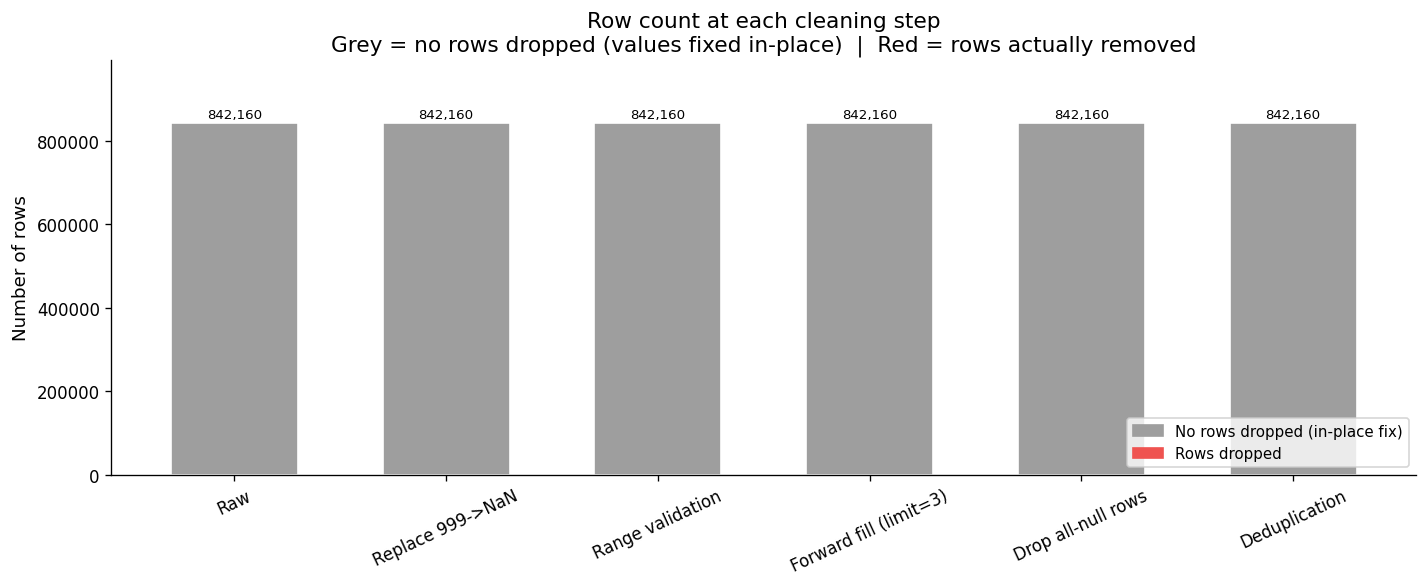

In [27]:
log_df = pd.DataFrame(cleaning_log)

print('CLEANING LOG')
print('=' * 90)
display(log_df)

total_removed = INITIAL_ROWS - len(df)
print(f'\nInitial rows  : {INITIAL_ROWS:,}')
print(f'Final rows    : {len(df):,}')
print(f'Total removed : {total_removed:,}  ({total_removed/INITIAL_ROWS*100:.2f}% of original)')

if total_removed == 0:
    print('\nNOTE: 0 rows removed is expected for this KNN-imputed file.')
    print('Cleaning operations still ran — they replaced bad values in-place.')

# ── Waterfall chart — show ALL steps, grey=no drop, red=rows dropped ───────
steps   = ['Raw'] + [r['step']         for r in cleaning_log]
counts  = [INITIAL_ROWS] + [r['rows_after']  for r in cleaning_log]
removed = [0] + [r['rows_removed'] for r in cleaning_log]

fig, ax = plt.subplots(figsize=(max(12, len(steps) * 1.8), 5))

colors = ['#9E9E9E' if r == 0 else '#EF5350' for r in removed]
bars   = ax.bar(steps, counts, color=colors, edgecolor='white', width=0.6)

for bar, val, rem in zip(bars, counts, removed):
    label = f'{val:,}' if rem == 0 else f'{val:,}\n(-{rem:,})'
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + INITIAL_ROWS * 0.008,
        label, ha='center', va='bottom', fontsize=8
    )

ax.set_ylabel('Number of rows')
ax.set_title(
    'Row count at each cleaning step\n'
    'Grey = no rows dropped (values fixed in-place)  |  Red = rows actually removed'
)
ax.tick_params(axis='x', rotation=25)
ax.set_ylim(0, INITIAL_ROWS * 1.18)

grey_p = mpatches.Patch(color='#9E9E9E', label='No rows dropped (in-place fix)')
red_p  = mpatches.Patch(color='#EF5350', label='Rows dropped')
ax.legend(handles=[grey_p, red_p], fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

---
## Section 10 — Before vs After: Pollutant Distributions

### What Should Change?

After cleaning:
- The spike at exactly 999 on the right side of each histogram should disappear
- Values beyond the physical maximum (red dashed line) should be gone
- The distribution should be smoother and more realistic
- Skewness values may change — document this as it matters for regression (right-skewed features may need log transformation)

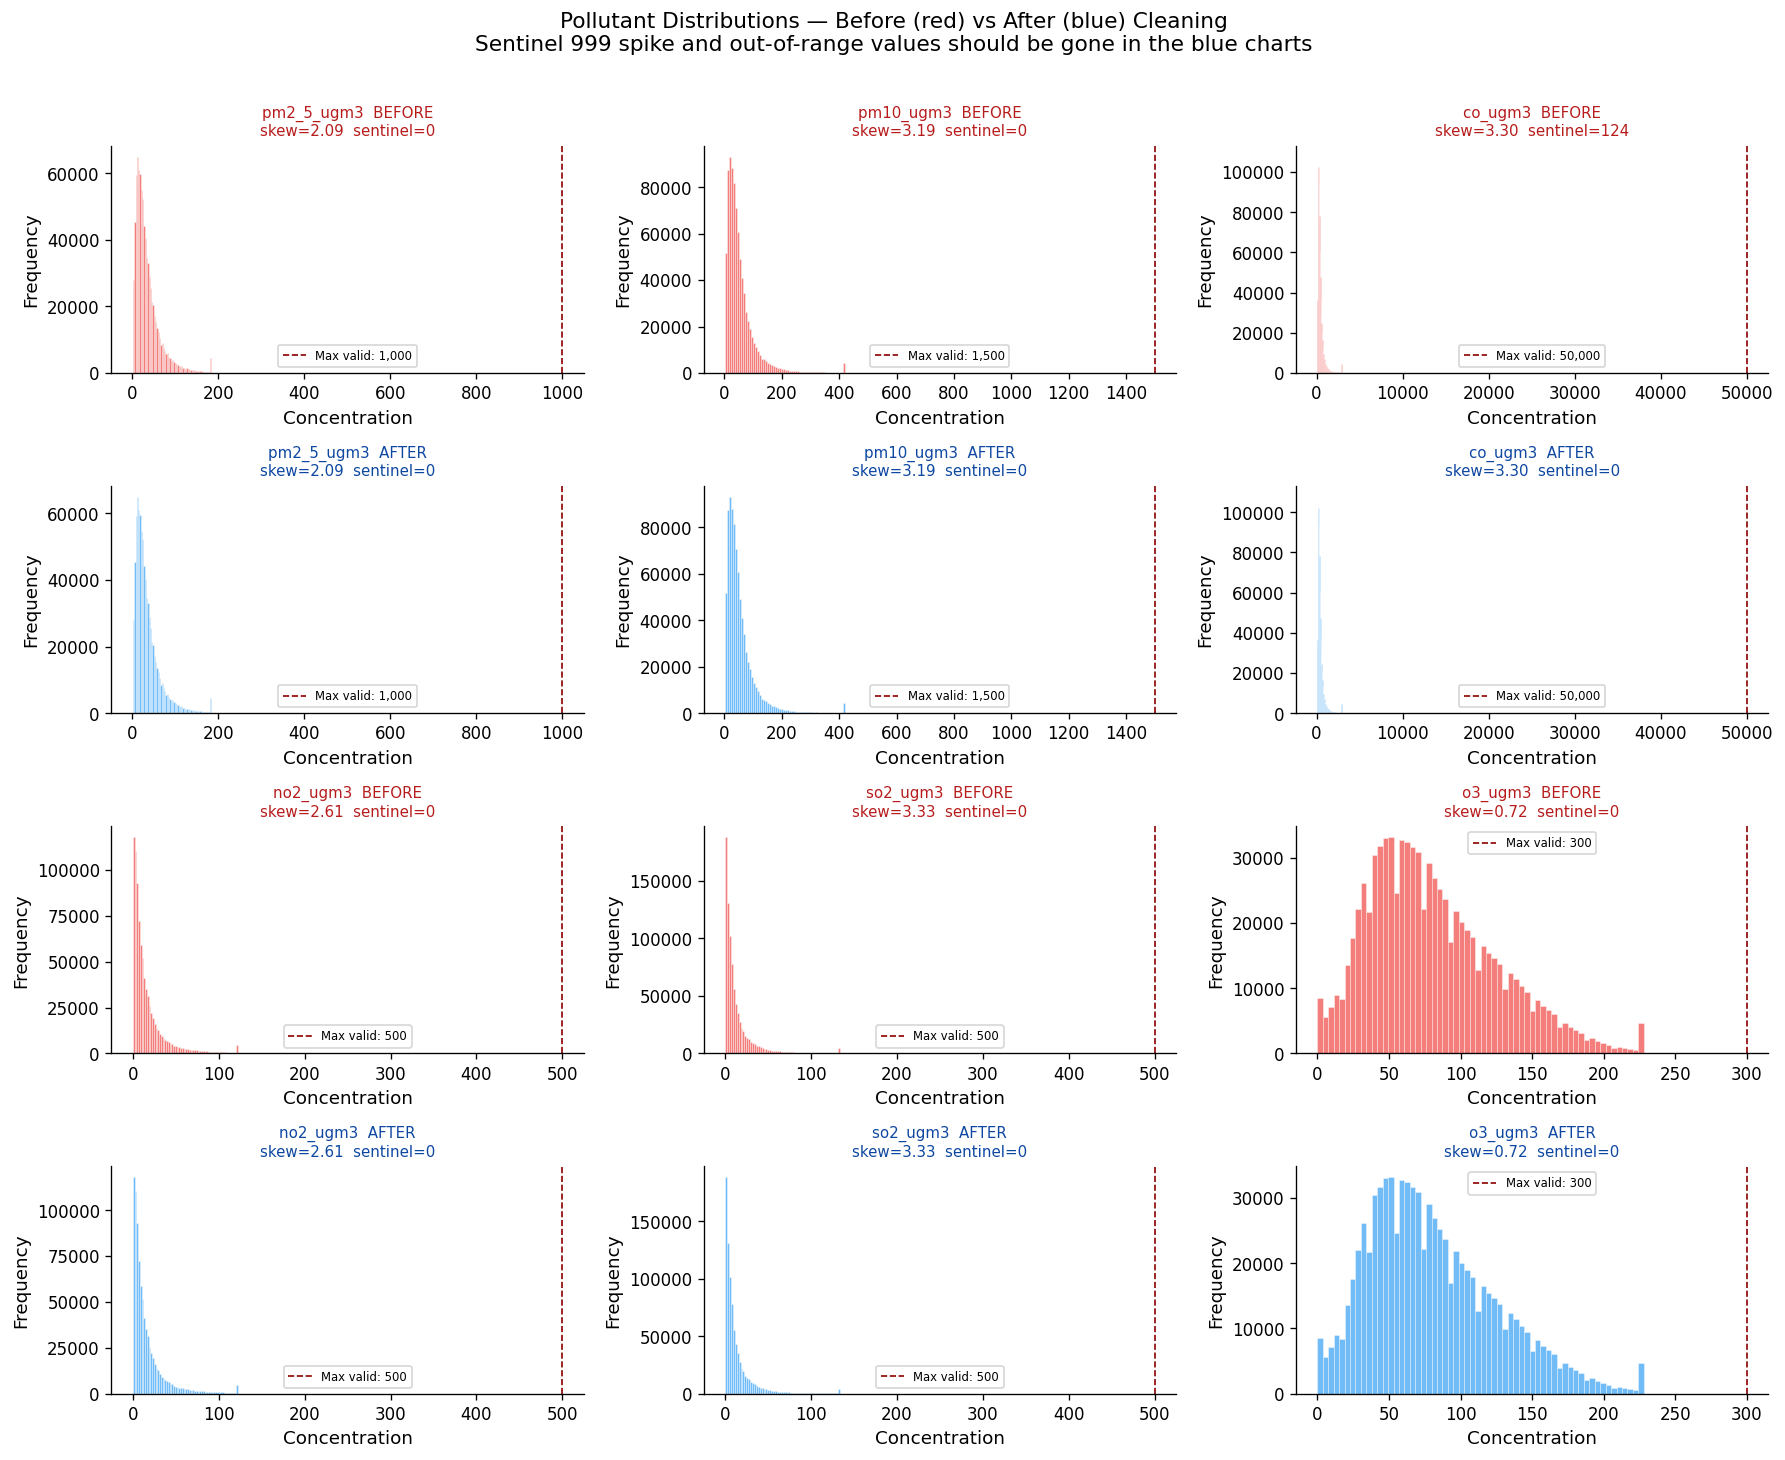

In [28]:
VALID_MAX_VIS = {
    'pm2':1000, 'pm10':1500, 'no2':500,
    'so2':500,  'co':50000,  'ozone':300,
    'o3':300,   'nh3':400
}

if pollutant_cols:
    n     = len(pollutant_cols)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows * 2, ncols,
                             figsize=(5 * ncols, nrows * 6),
                             squeeze=False)

    for i, col in enumerate(pollutant_cols):
        row_b = (i // ncols) * 2
        row_a = row_b + 1
        col_i = i % ncols

        raw_vals   = pd.to_numeric(df_raw_snapshot[col], errors='coerce').dropna()
        clean_vals = pd.to_numeric(df[col],              errors='coerce').dropna()

        vis_cap = 1200
        for kw, maxval in VALID_MAX_VIS.items():
            if kw in col.lower():
                vis_cap = maxval * 1.2
                break

        raw_vis   = raw_vals[raw_vals     <= vis_cap]
        clean_vis = clean_vals[clean_vals <= vis_cap]

        s_before = (raw_vals   == 999).sum()
        s_after  = (clean_vals == 999).sum()

        ax_b = axes[row_b][col_i]
        ax_a = axes[row_a][col_i]

        ax_b.hist(raw_vis,   bins=60, color='#EF5350', alpha=0.75,
                  edgecolor='white', linewidth=0.3)
        ax_b.set_title(
            f'{col}  BEFORE\nskew={raw_vis.skew():.2f}  sentinel={s_before:,}',
            fontsize=9, color='#B71C1C'
        )

        ax_a.hist(clean_vis, bins=60, color='#42A5F5', alpha=0.75,
                  edgecolor='white', linewidth=0.3)
        ax_a.set_title(
            f'{col}  AFTER\nskew={clean_vis.skew():.2f}  sentinel={s_after:,}',
            fontsize=9, color='#0D47A1'
        )

        for ax in [ax_b, ax_a]:
            ax.set_xlabel('Concentration')
            ax.set_ylabel('Frequency')
            for kw, maxval in VALID_MAX_VIS.items():
                if kw in col.lower():
                    ax.axvline(min(maxval, vis_cap), color='darkred',
                               linestyle='--', linewidth=1,
                               label=f'Max valid: {maxval:,}')
                    ax.legend(fontsize=7)
                    break

    for j in range(i + 1, nrows * ncols):
        r = (j // ncols) * 2
        c = j % ncols
        for offset in [0, 1]:
            if r + offset < len(axes):
                axes[r + offset][c].set_visible(False)

    plt.suptitle(
        'Pollutant Distributions — Before (red) vs After (blue) Cleaning\n'
        'Sentinel 999 spike and out-of-range values should be gone in the blue charts',
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    plt.show()

---
## Section 11 — Before vs After: Correlation Heatmap

Sentinel values distort correlations. When PM2.5=999 and CO=999 occur on the same row, it creates a false strong correlation. After removing sentinels the true structure becomes visible.

The correlation of each pollutant with AQI tells us which features will be most predictive for the regression model.

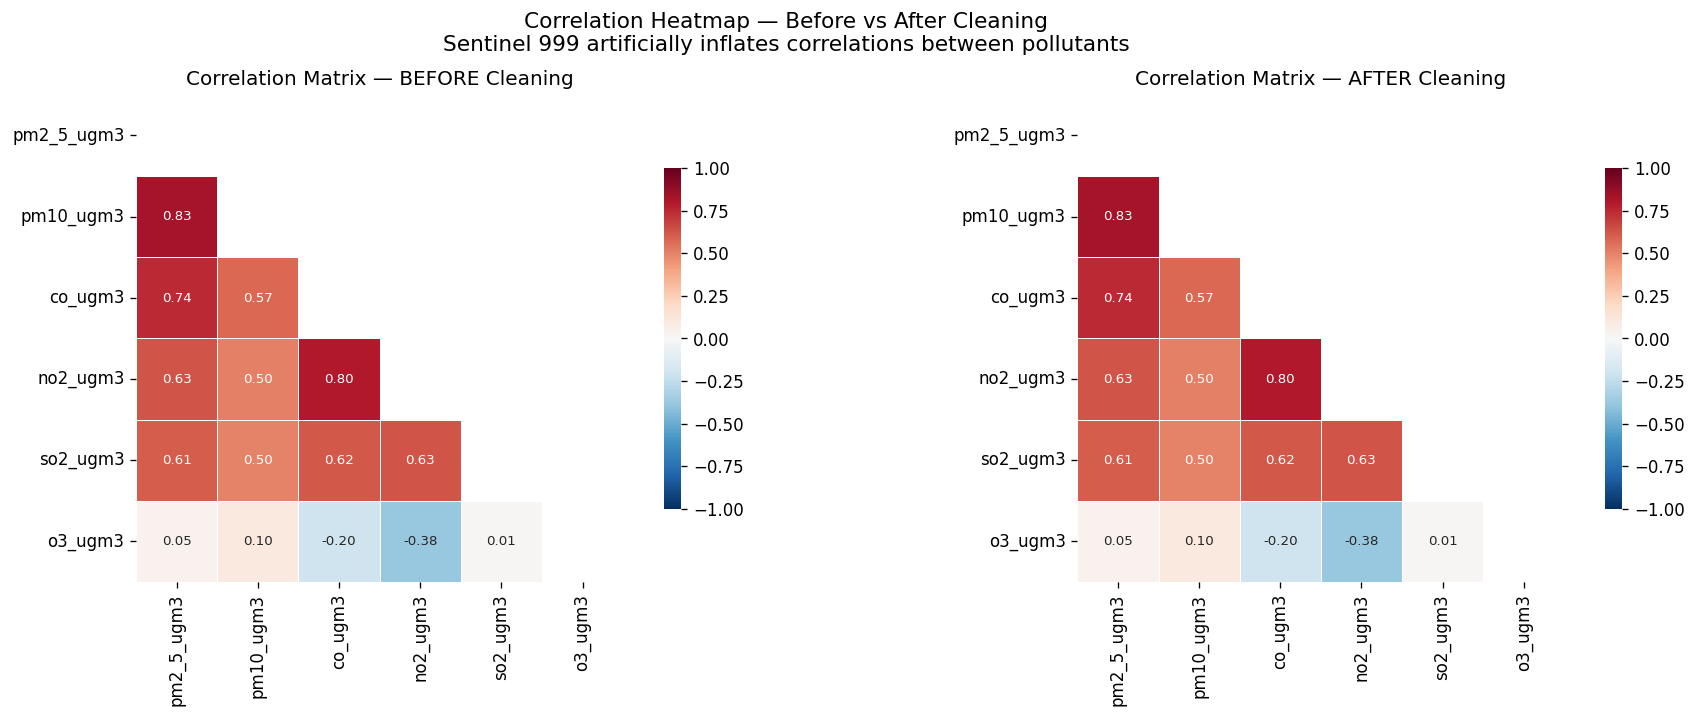

In [29]:
corr_cols = pollutant_cols.copy()
if aqi_col and aqi_col in df.columns:
    corr_cols.append(aqi_col)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, source_df, title in [
    (axes[0], df_raw_snapshot[pollutant_cols], 'BEFORE Cleaning'),
    (axes[1], df[corr_cols],                   'AFTER Cleaning'),
]:
    corr_mat = source_df.apply(pd.to_numeric, errors='coerce').corr()
    mask     = np.triu(np.ones_like(corr_mat, dtype=bool))
    sns.heatmap(
        corr_mat, mask=mask, annot=True, fmt='.2f',
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.5, ax=ax,
        cbar_kws={'shrink': 0.7}, annot_kws={'size': 8}
    )
    ax.set_title(f'Correlation Matrix — {title}', fontsize=12)

plt.suptitle(
    'Correlation Heatmap — Before vs After Cleaning\n'
    'Sentinel 999 artificially inflates correlations between pollutants',
    fontsize=13
)
plt.tight_layout()
plt.show()

if aqi_col and aqi_col in df.columns:
    clean_corr = df[corr_cols].apply(pd.to_numeric, errors='coerce').corr()
    if aqi_col in clean_corr.columns:
        aqi_corr = (clean_corr[aqi_col]
                    .drop(aqi_col)
                    .sort_values(key=abs, ascending=False))
        print('Pollutant correlation with AQI (after cleaning):')
        print(aqi_corr.to_string())
        print('\nHighest absolute correlation = strongest predictor for regression.')

---
## Section 12 — Final Null Check

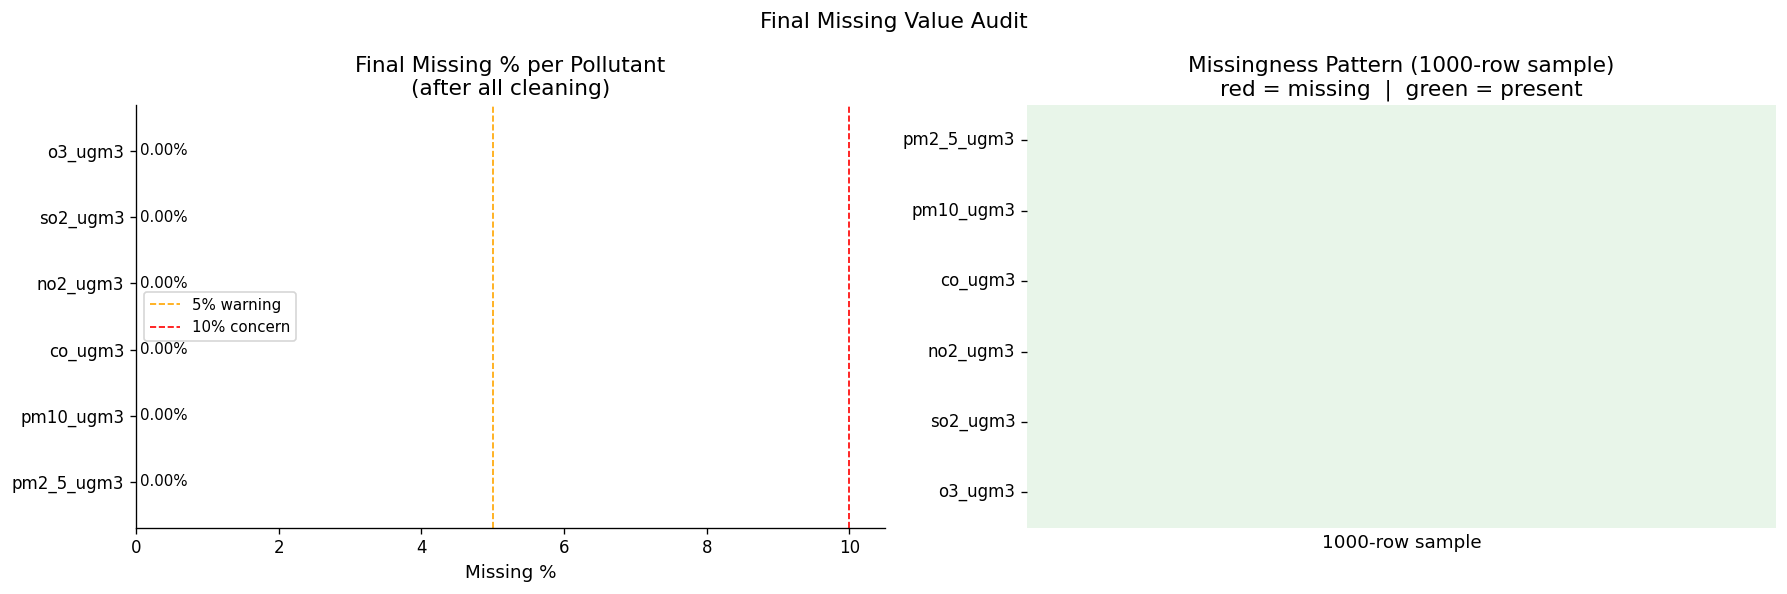

In [30]:
final_null_pct = df[pollutant_cols].isnull().mean() * 100
final_null_pct = final_null_pct.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = ['#EF5350' if v > 10 else '#FFA726' if v > 5 else '#66BB6A'
          for v in final_null_pct.values]
bars   = axes[0].barh(final_null_pct.index, final_null_pct.values, color=colors)
axes[0].axvline(5,  color='orange', linestyle='--', linewidth=1, label='5% warning')
axes[0].axvline(10, color='red',    linestyle='--', linewidth=1, label='10% concern')
axes[0].set_xlabel('Missing %')
axes[0].set_title('Final Missing % per Pollutant\n(after all cleaning)')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, final_null_pct.values):
    axes[0].text(val + 0.05, bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}%', va='center', fontsize=9)

sample_df = df[pollutant_cols].sample(min(1000, len(df)), random_state=42)
sns.heatmap(
    sample_df.isnull().T,
    cmap=['#E8F5E9', '#EF5350'],
    cbar=False, ax=axes[1],
    yticklabels=True, xticklabels=False
)
axes[1].set_xlabel('1000-row sample')
axes[1].set_title('Missingness Pattern (1000-row sample)\nred = missing  |  green = present')

plt.suptitle('Final Missing Value Audit', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 13 — AQI Category Distribution After Cleaning

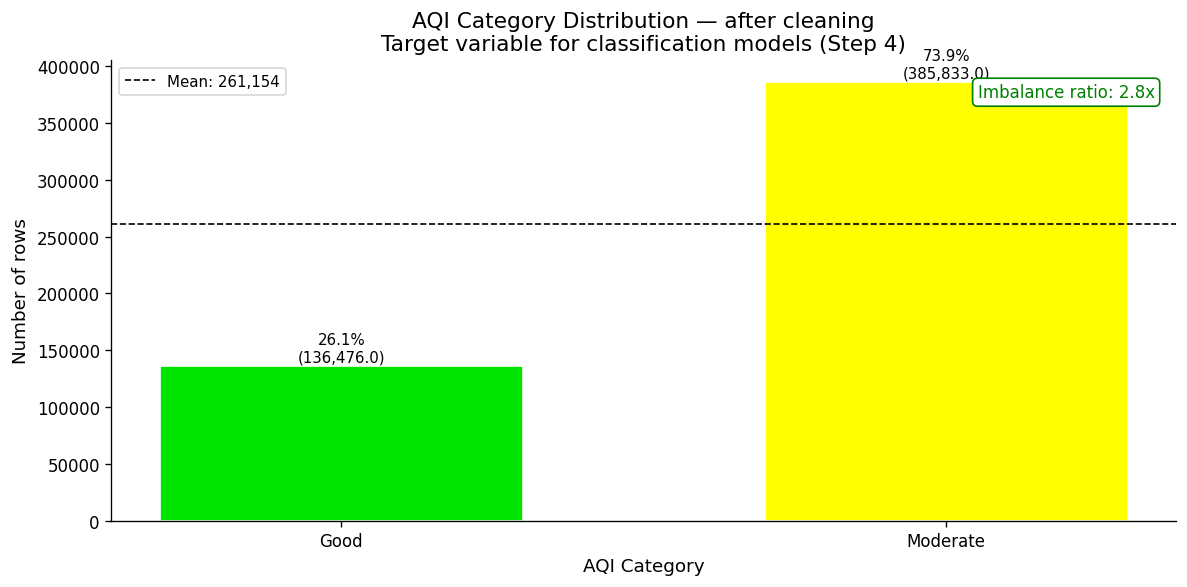

In [31]:
if cat_col and cat_col in df.columns:
    cat_order  = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']
    cat_colors = ['#00E400','#92D050','#FFFF00','#FF7E00','#FF0000','#99004C']

    cat_vals = df[cat_col].astype(str).str.strip().str.title()
    counts   = cat_vals.value_counts().reindex(cat_order).dropna()
    pcts     = (counts / counts.sum() * 100).round(1)
    clrs     = [cat_colors[cat_order.index(c)] for c in counts.index if c in cat_order]

    fig, ax  = plt.subplots(figsize=(10, 5))
    bars     = ax.bar(counts.index, counts.values, color=clrs,
                      edgecolor='white', width=0.6)
    ax.axhline(counts.mean(), color='black', linestyle='--',
               linewidth=1, label=f'Mean: {counts.mean():,.0f}')

    for bar, pct, val in zip(bars, pcts.values, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + counts.max() * 0.01,
                f'{pct:.1f}%\n({val:,})', ha='center', fontsize=9)

    ax.set_xlabel('AQI Category')
    ax.set_ylabel('Number of rows')
    ax.set_title(
        'AQI Category Distribution — after cleaning\n'
        'Target variable for classification models (Step 4)'
    )
    ax.legend(fontsize=9)

    imb_ratio  = counts.max() / counts.min()
    warn_color = 'red' if imb_ratio > 5 else 'orange' if imb_ratio > 3 else 'green'
    ax.text(0.98, 0.95, f'Imbalance ratio: {imb_ratio:.1f}x',
            ha='right', va='top', transform=ax.transAxes,
            fontsize=10, color=warn_color,
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white', edgecolor=warn_color))

    plt.tight_layout()
    plt.show()

    if imb_ratio > 3:
        print(f'WARNING: {imb_ratio:.1f}x class imbalance.')
        print('Step 4 (classification) will apply SMOTE or class_weight to handle this.')

---
## Section 14 — Save Master Cleaned File

Saved in two formats:
- **Parquet** — compressed, loads 5–10x faster than CSV. Install with `pip install pyarrow`. Skipped gracefully if not available.
- **CSV** — always saved regardless. Use for inspection or sharing.

In [32]:
PARQUET_PATH = os.path.join(SHARED_DIR, 'master_cleaned.parquet')
CSV_PATH     = os.path.join(SHARED_DIR, 'master_cleaned.csv')
LOG_PATH     = os.path.join(SHARED_DIR, 'cleaning_log.csv')

# ── Save parquet (fast format) — skip gracefully if pyarrow not installed ──
try:
    df.to_parquet(PARQUET_PATH, index=False)
    parquet_mb = os.path.getsize(PARQUET_PATH) / 1024**2
    print(f'  Parquet saved : {PARQUET_PATH}  ({parquet_mb:.1f} MB)')
    print('  TIP: Use this file in Steps 3-6 — loads much faster than CSV')
except ImportError:
    PARQUET_PATH = None
    print('  Parquet skipped — pyarrow not installed')
    print('  To enable: run  pip install pyarrow  in your terminal then restart kernel')
    print('  Steps 3-6 will fall back to reading the CSV instead')

# ── Always save CSV ─────────────────────────────────────────────────────────
df.to_csv(CSV_PATH, index=False)
log_df.to_csv(LOG_PATH, index=False)

csv_mb = os.path.getsize(CSV_PATH) / 1024**2
print(f'  CSV saved     : {CSV_PATH}  ({csv_mb:.1f} MB)')
print(f'  Log saved     : {LOG_PATH}')

print()
print('=' * 60)
print('  STEP 2 COMPLETE')
print('=' * 60)
print(f'  Initial rows          : {INITIAL_ROWS:,}')
print(f'  Final rows            : {len(df):,}')
print(f'  Rows removed          : {INITIAL_ROWS - len(df):,}')
print(f'  Columns               : {df.shape[1]}')
print(f'  Sentinel values fixed : {sum(raw_sentinel_counts.values()):,}')
print()
print('  NEXT: Run vayu_step3_regression.ipynb')
print('        Run vayu_step4_classification.ipynb')
print('        Run vayu_step5_clustering.ipynb')
print('        Run vayu_step6_dimensionality.ipynb')
print('=' * 60)

  Parquet skipped — pyarrow not installed
  To enable: run  pip install pyarrow  in your terminal then restart kernel
  Steps 3-6 will fall back to reading the CSV instead
  CSV saved     : ./data/cleaned/05_shared/master_cleaned.csv  (172.2 MB)
  Log saved     : ./data/cleaned/05_shared/cleaning_log.csv

  STEP 2 COMPLETE
  Initial rows          : 842,160
  Final rows            : 842,160
  Rows removed          : 0
  Columns               : 35
  Sentinel values fixed : 124

  NEXT: Run vayu_step3_regression.ipynb
        Run vayu_step4_classification.ipynb
        Run vayu_step5_clustering.ipynb
        Run vayu_step6_dimensionality.ipynb
